# Taxi Trip Pricing: регрессия на реальных данных

**Задача:** от EDA до честного вердикта — предсказать `Trip_Price`.

Датасет: `taxi_trip_pricing.csv` — 1000 поездок, 11 колонок.

**Особенности:**
- Есть **пропуски** (~50 в каждой колонке) → нужна обработка NaN.
- Цель `Trip_Price`, скорее всего, считается из `Base_Fare + Per_Km_Rate * distance + Per_Minute_Rate * duration` → проверь, не будет ли подозрительно высокого R² (почти детерминированная формула — сюжет для честного вердикта).

**Категориальные (object):** Time_of_Day, Day_of_Week, Traffic_Conditions, Weather.  
**Числовые:** Trip_Distance_km, Passenger_Count, Base_Fare, Per_Km_Rate, Per_Minute_Rate, Trip_Duration_Minutes.

In [111]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [112]:
df = pd.read_csv("data/taxi_trip_pricing.csv")
df.shape

(1000, 11)

In [113]:
df.head()

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
0,19.35,Morning,Weekday,3.0,Low,Clear,3.56,0.80,0.32,53.82,36.2624
1,47.59,Afternoon,Weekday,1.0,High,Clear,NaN,0.62,0.43,40.57,NaN
2,36.87,Evening,Weekend,1.0,High,Clear,2.70,1.21,0.15,37.27,52.9032
3,30.33,Evening,Weekday,4.0,Low,NaN,3.48,0.51,0.15,116.81,36.4698
4,NaN,Evening,Weekday,3.0,High,Clear,2.93,0.63,0.32,22.64,15.6180


In [114]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Trip_Distance_km       950 non-null    float64
 1   Time_of_Day            950 non-null    object 
 2   Day_of_Week            950 non-null    object 
 3   Passenger_Count        950 non-null    float64
 4   Traffic_Conditions     950 non-null    object 
 5   Weather                950 non-null    object 
 6   Base_Fare              950 non-null    float64
 7   Per_Km_Rate            950 non-null    float64
 8   Per_Minute_Rate        950 non-null    float64
 9   Trip_Duration_Minutes  950 non-null    float64
 10  Trip_Price             951 non-null    float64
dtypes: float64(7), object(4)
memory usage: 86.1+ KB


In [115]:
# Пропуски по колонкам
df.isnull().sum()

Trip_Distance_km         50
Time_of_Day              50
Day_of_Week              50
Passenger_Count          50
Traffic_Conditions       50
Weather                  50
Base_Fare                50
Per_Km_Rate              50
Per_Minute_Rate          50
Trip_Duration_Minutes    50
Trip_Price               49
dtype: int64

In [116]:
df.describe(include="all")

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
count,950.000000,950,950,950.000000,950,950,950.000000,950.000000,950.000000,950.000000,951.000000
unique,NaN,4,2,NaN,3,3,NaN,NaN,NaN,NaN,NaN
top,NaN,Afternoon,Weekday,NaN,Low,Clear,NaN,NaN,NaN,NaN,NaN
freq,NaN,371,655,NaN,397,667,NaN,NaN,NaN,NaN,NaN
mean,27.070547,NaN,NaN,2.476842,NaN,NaN,3.502989,1.233316,0.292916,62.118116,56.874773
std,19.905300,NaN,NaN,1.102249,NaN,NaN,0.870162,0.429816,0.115592,32.154406,40.469791
min,1.230000,NaN,NaN,1.000000,NaN,NaN,2.010000,0.500000,0.100000,5.010000,6.126900
25%,12.632500,NaN,NaN,1.250000,NaN,NaN,2.730000,0.860000,0.190000,35.882500,33.742650
50%,25.830000,NaN,NaN,2.000000,NaN,NaN,3.520000,1.220000,0.290000,61.860000,50.074500
75%,38.405000,NaN,NaN,3.000000,NaN,NaN,4.260000,1.610000,0.390000,89.055000,69.099350


In [117]:
df.describe()

,Trip_Distance_km,Passenger_Count,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
count,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,951.000000
mean,27.070547,2.476842,3.502989,1.233316,0.292916,62.118116,56.874773
std,19.905300,1.102249,0.870162,0.429816,0.115592,32.154406,40.469791
min,1.230000,1.000000,2.010000,0.500000,0.100000,5.010000,6.126900
25%,12.632500,1.250000,2.730000,0.860000,0.190000,35.882500,33.742650
50%,25.830000,2.000000,3.520000,1.220000,0.290000,61.860000,50.074500
75%,38.405000,3.000000,4.260000,1.610000,0.390000,89.055000,69.099350
max,146.067047,4.000000,5.000000,2.000000,0.500000,119.840000,332.043689


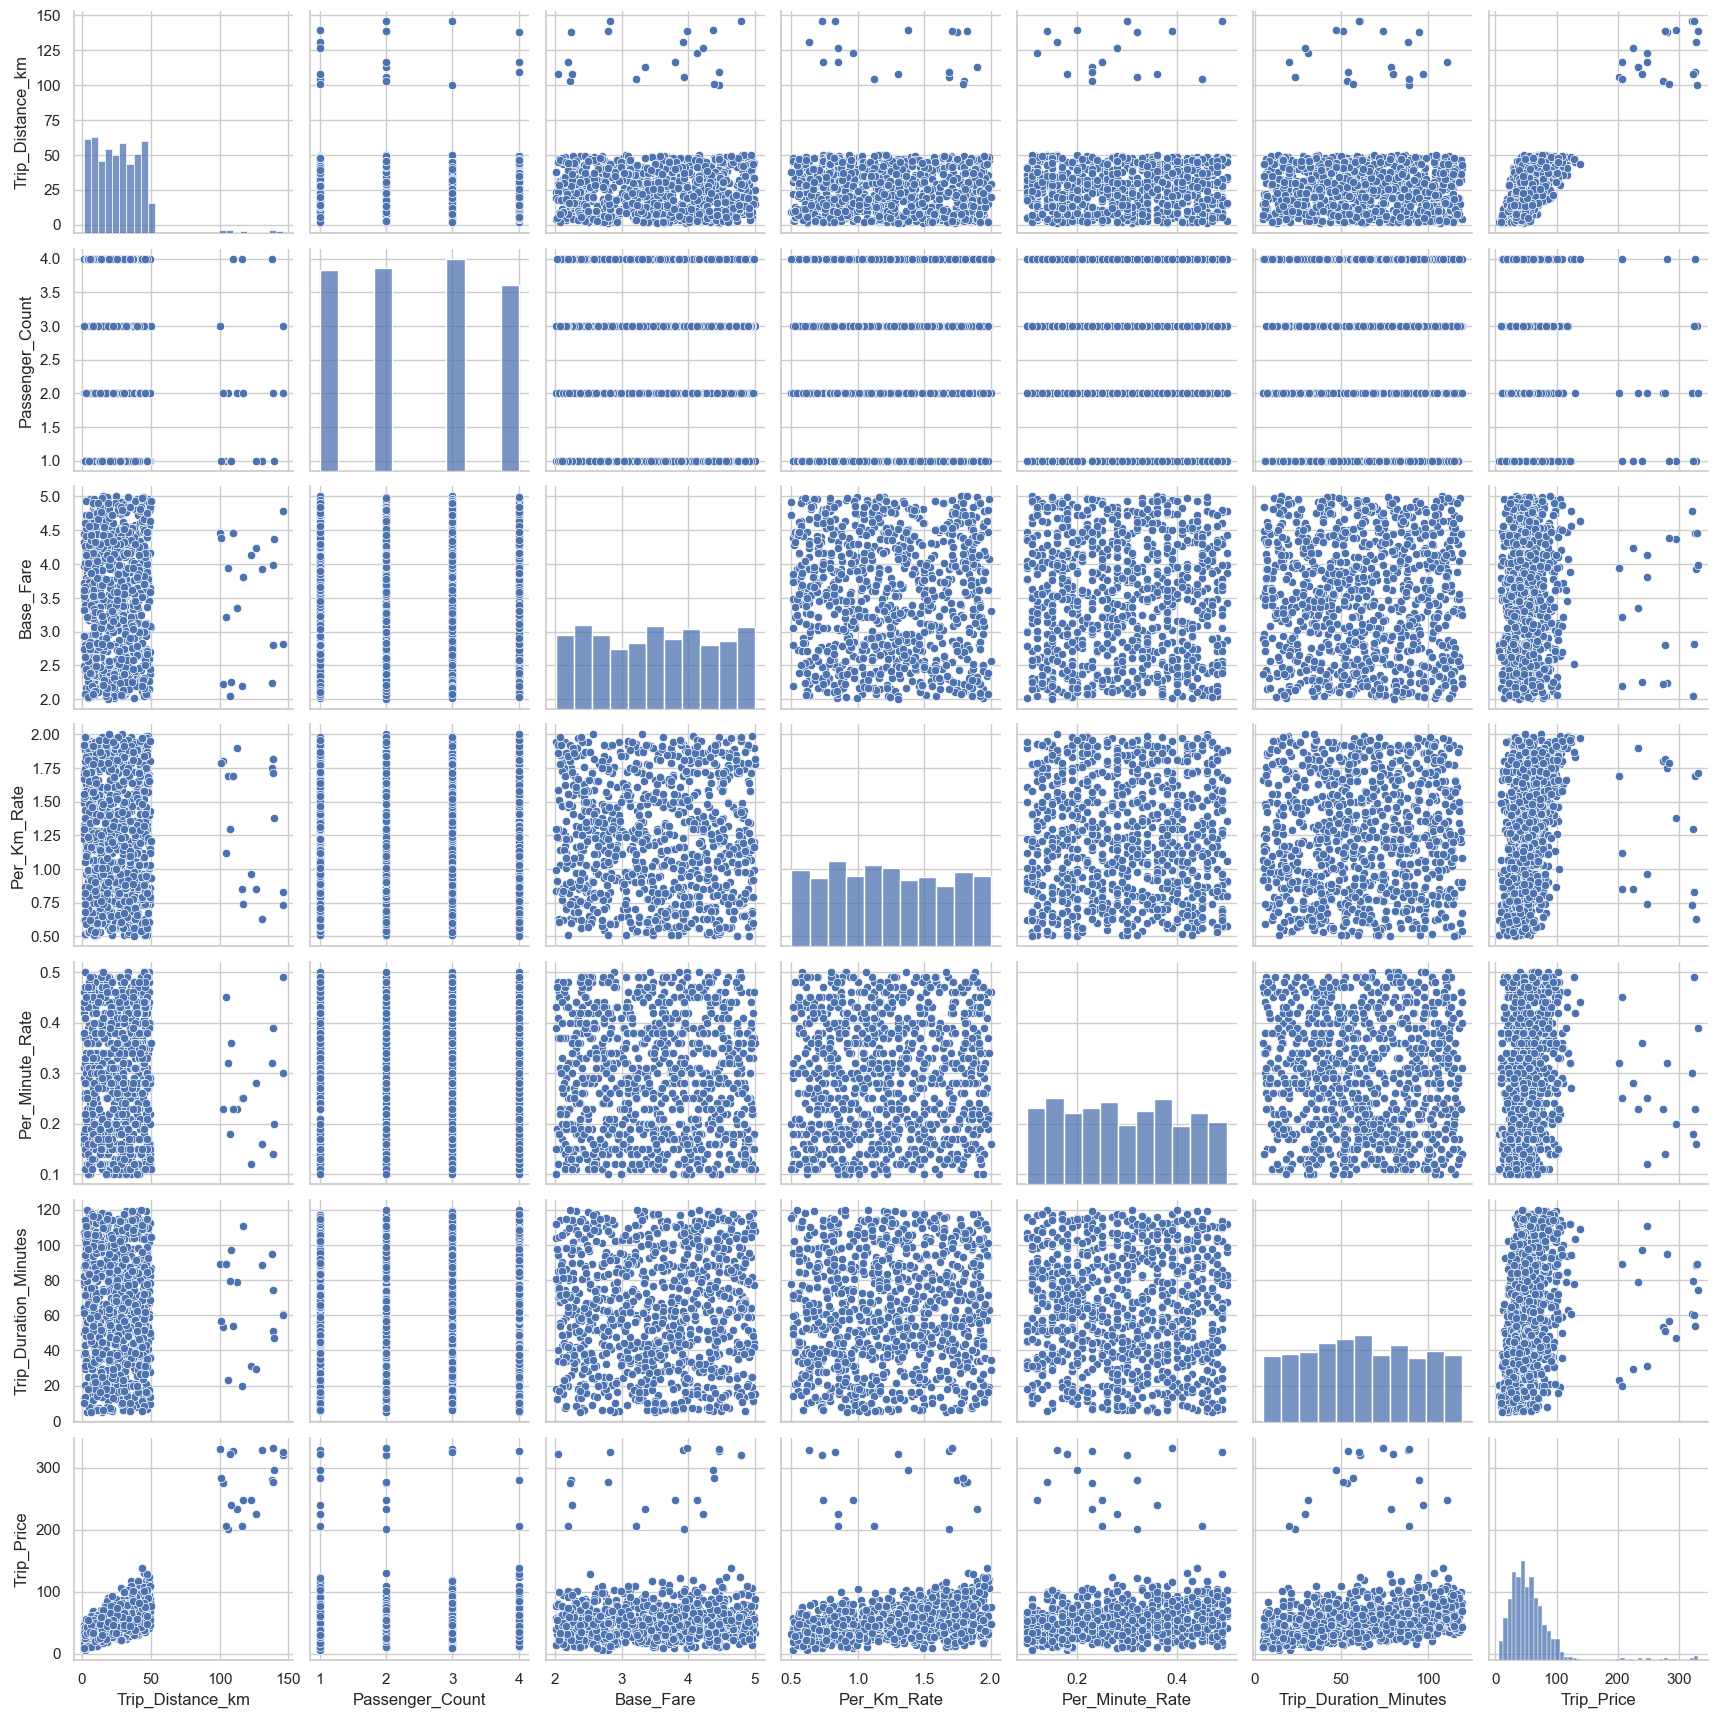

In [118]:
sns.pairplot(df)

<Axes: xlabel='Trip_Duration_Minutes', ylabel='Count'>

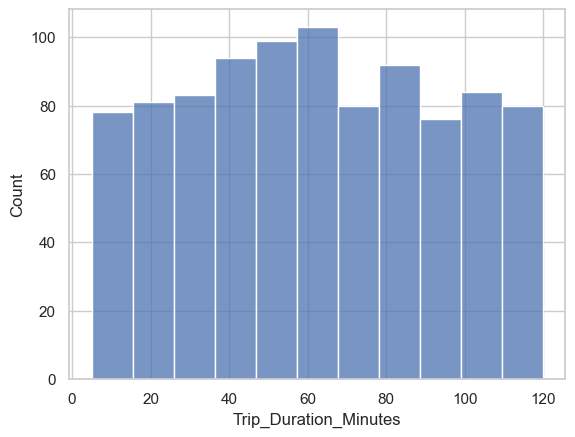

In [119]:
sns.histplot(df['Trip_Duration_Minutes'])

<Axes: >

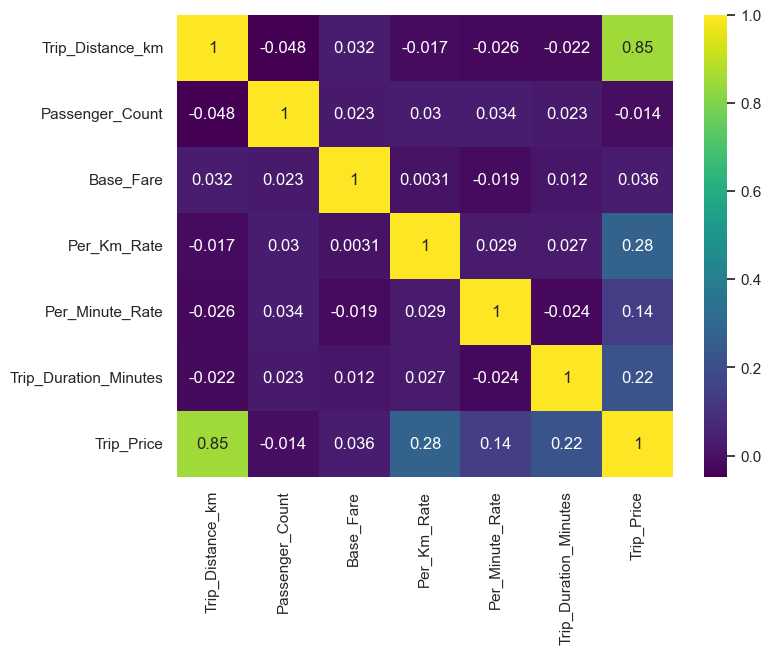

In [120]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True),cmap='viridis',annot=True)

## Очистка данных

**Что делаем и почему:**
- Дубликатов нет.
- Строк хотя бы с одним пропуском — 438 из 1000 (44%), поэтому `dropna()` по всем строкам убил бы почти половину данных → так нельзя.
- **Цель `Trip_Price`**: 49 строк с NaN → дропаем (метку для обучения не придумываем).
- **Числовые признаки**: импьютируем медианой (устойчива к выбросам — дистанция тянется до 146 км).
- **Категориальные признаки**: импьютируем модой.

In [121]:
# Копия, чтобы не трогать исходный df
df_clean = df.copy()

# 1) Дубликаты
df_clean = df_clean.drop_duplicates()

# 2) Строки с пропущенной целью — удаляем
before = len(df_clean)
df_clean = df_clean.dropna(subset=["Trip_Price"])
print(f"Удалено строк с пустым Trip_Price: {before - len(df_clean)}")

Удалено строк с пустым Trip_Price: 49


In [122]:
# 3) Импутация признаков
num_cols = ["Trip_Distance_km", "Passenger_Count", "Base_Fare",
            "Per_Km_Rate", "Per_Minute_Rate", "Trip_Duration_Minutes"]
cat_cols = ["Time_of_Day", "Day_of_Week", "Traffic_Conditions", "Weather"]

for c in num_cols:
    df_clean[c] = df_clean[c].fillna(df_clean[c].median())

for c in cat_cols:
    df_clean[c] = df_clean[c].fillna(df_clean[c].mode()[0])

# Passenger_Count по смыслу целое
df_clean["Passenger_Count"] = df_clean["Passenger_Count"].astype(int)

In [123]:
# 4) Проверка: пропусков быть не должно
print("Осталось строк:", len(df_clean))
print("Всего пропусков:", df_clean.isnull().sum().sum())
df_clean.isnull().sum()

Осталось строк: 951
Всего пропусков: 0


Trip_Distance_km         0
Time_of_Day              0
Day_of_Week              0
Passenger_Count          0
Traffic_Conditions       0
Weather                  0
Base_Fare                0
Per_Km_Rate              0
Per_Minute_Rate          0
Trip_Duration_Minutes    0
Trip_Price               0
dtype: int64

In [124]:
# Сохраняем очищенную версию для дальнейшей работы
df_clean.to_csv("data/taxi_trip_pricing_clean.csv", index=False)
df_clean.head()

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
0,19.35,Morning,Weekday,3,Low,Clear,3.56,0.80,0.32,53.82,36.2624
2,36.87,Evening,Weekend,1,High,Clear,2.70,1.21,0.15,37.27,52.9032
3,30.33,Evening,Weekday,4,Low,Clear,3.48,0.51,0.15,116.81,36.4698
4,25.87,Evening,Weekday,3,High,Clear,2.93,0.63,0.32,22.64,15.6180
5,8.64,Afternoon,Weekend,2,Medium,Clear,2.55,1.71,0.48,89.33,60.2028


## Распределение целевой переменной

Смотрим форму `Trip_Price`: симметрично или скошено, есть ли длинный хвост (дорогие поездки) и выбросы. Если асимметрия сильная (`skew > 1`), пробуем `log`-преобразование — это материал для честного вердикта о том, где модель будет ошибаться.

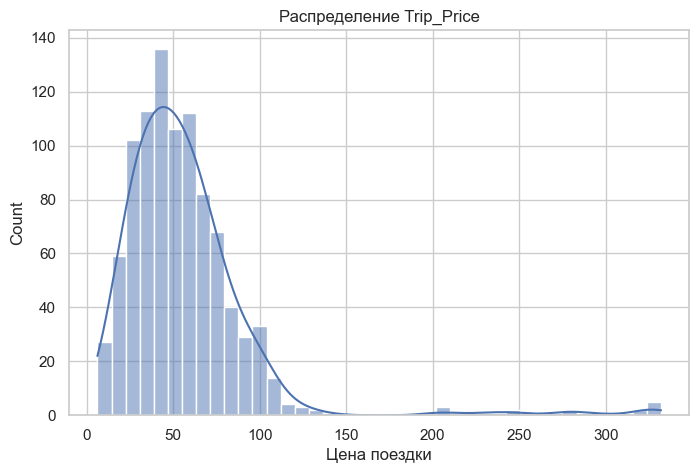

skew (асимметрия): 3.73


In [125]:
# Распределение целевой переменной
plt.figure(figsize=(8, 5))
sns.histplot(df_clean["Trip_Price"], kde=True, bins=40)
plt.title("Распределение Trip_Price")
plt.xlabel("Цена поездки")
plt.show()

print("skew (асимметрия):", round(df_clean["Trip_Price"].skew(), 2))

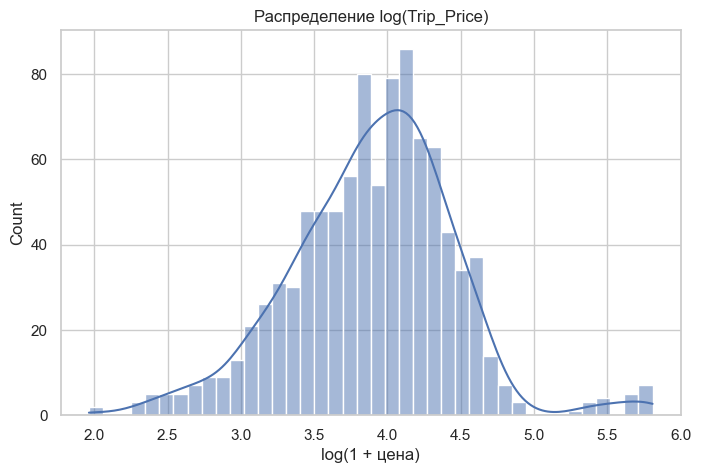

skew после log: 0.0


In [126]:
# Если хвост сильный — пробуем log-преобразование цели
plt.figure(figsize=(8, 5))
sns.histplot(np.log1p(df_clean["Trip_Price"]), kde=True, bins=40)
plt.title("Распределение log(Trip_Price)")
plt.xlabel("log(1 + цена)")
plt.show()

print("skew после log:", round(np.log1p(df_clean["Trip_Price"]).skew(), 2))

## Таблица корреляции

Матрица корреляции по числовым признакам + отдельно — связь каждого признака с целью `Trip_Price`. Смотрим:
- какие признаки сильнее всего связаны с ценой (кандидаты в важные предикторы);
- нет ли сильной корреляции **между признаками** (мультиколлинеарность — мешает интерпретации коэффициентов линейной регрессии).

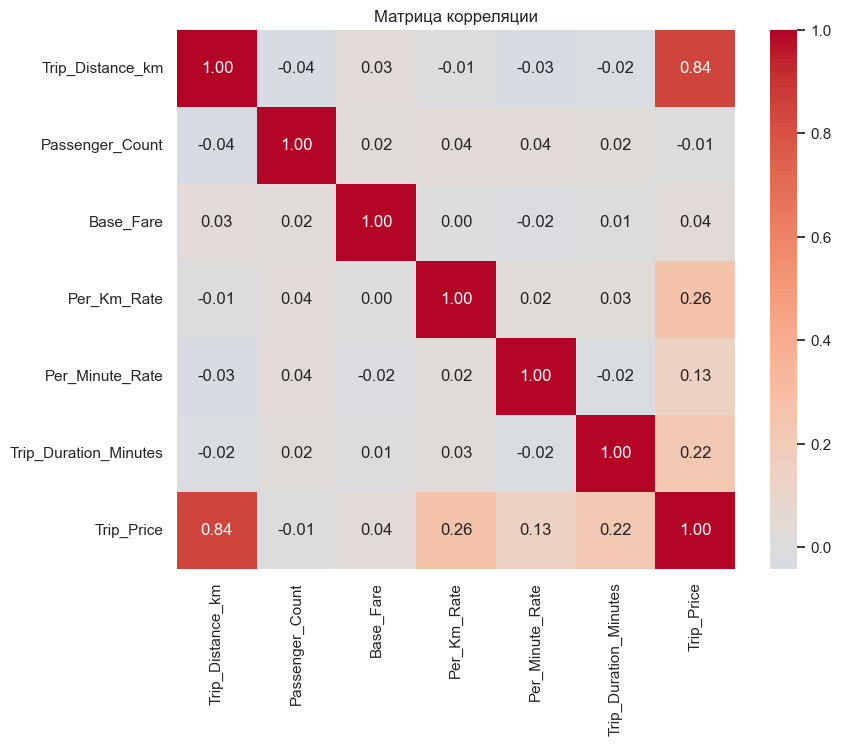

In [127]:
# Матрица корреляции (только числовые колонки)
plt.figure(figsize=(9, 7))
sns.heatmap(df_clean.corr(numeric_only=True), annot=True, fmt=".2f",
            cmap="coolwarm", center=0)
plt.title("Матрица корреляции")
plt.show()

In [128]:
# Корреляция признаков с целью (по убыванию силы связи)
corr_with_target = (
    df_clean.corr(numeric_only=True)["Trip_Price"]
    .drop("Trip_Price")
    .sort_values(key=abs, ascending=False)
)
corr_with_target

Trip_Distance_km         0.841818
Per_Km_Rate              0.263500
Trip_Duration_Minutes    0.219380
Per_Minute_Rate          0.133910
Base_Fare                0.035161
Passenger_Count         -0.013172
Name: Trip_Price, dtype: float64

## Описательные графики

Описываем датасет визуально:
1. **Распределения числовых признаков** (гистограммы) — форма, скошенность.
2. **Boxplot числовых** — выбросы и хвосты.
3. **Баланс категорий** (countplot) — равномерны ли категории.
4. **Признак → цена**: scatter для числовых, boxplot цены по категориям.

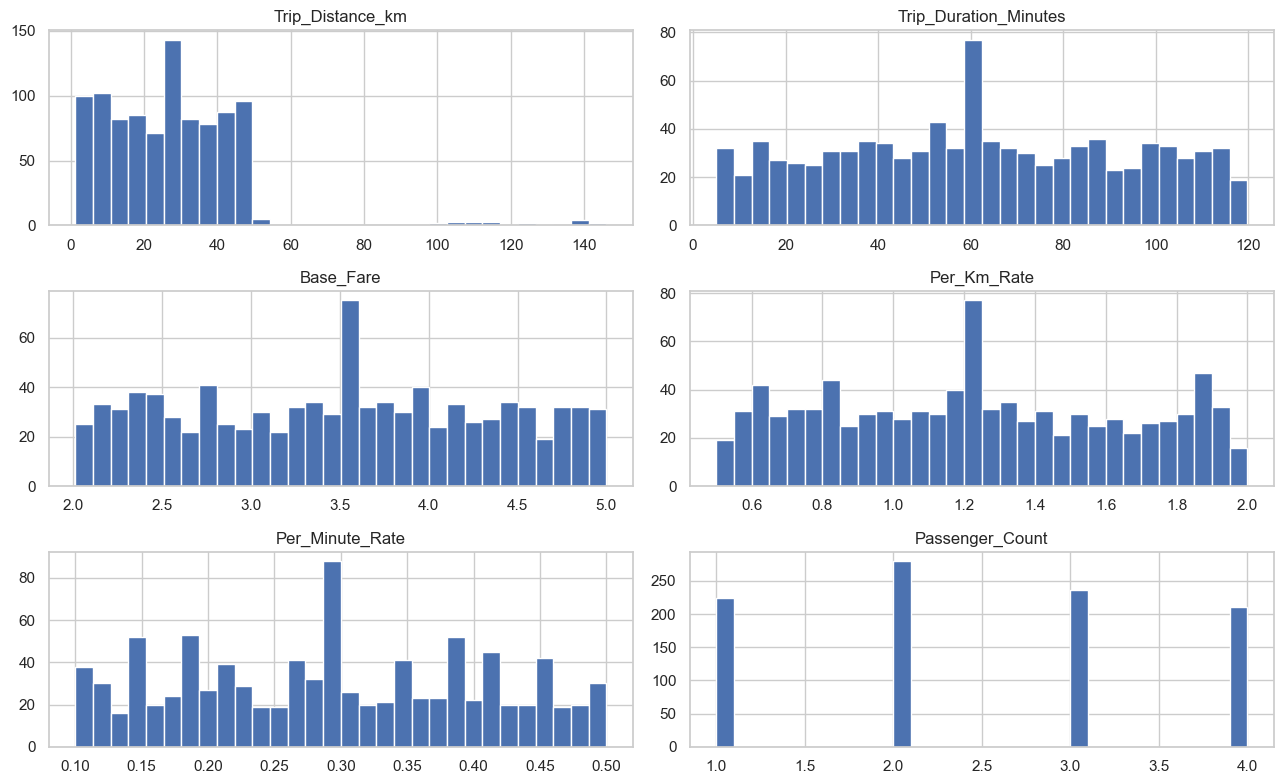

In [129]:
# Распределения числовых признаков
df_clean[["Trip_Distance_km", "Trip_Duration_Minutes", "Base_Fare",
          "Per_Km_Rate", "Per_Minute_Rate", "Passenger_Count"]].hist(bins=30, figsize=(13, 8))
plt.tight_layout()
plt.show()

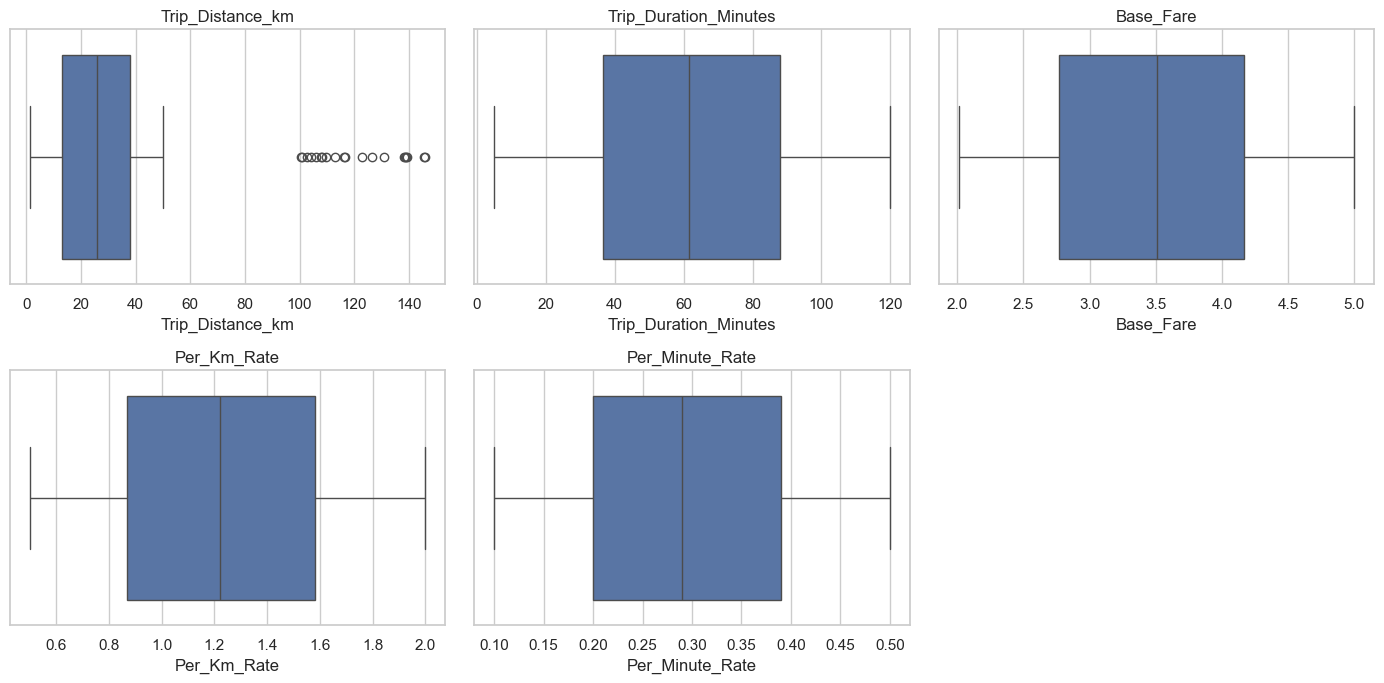

In [130]:
# Boxplot числовых признаков — выбросы и хвосты
dist_cols = ["Trip_Distance_km", "Trip_Duration_Minutes", "Base_Fare",
             "Per_Km_Rate", "Per_Minute_Rate"]
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, c in zip(axes.flat, dist_cols):
    sns.boxplot(data=df_clean, x=c, ax=ax)
    ax.set_title(c)
axes.flat[-1].set_visible(False)  # лишняя пустая ячейка сетки
plt.tight_layout()
plt.show()

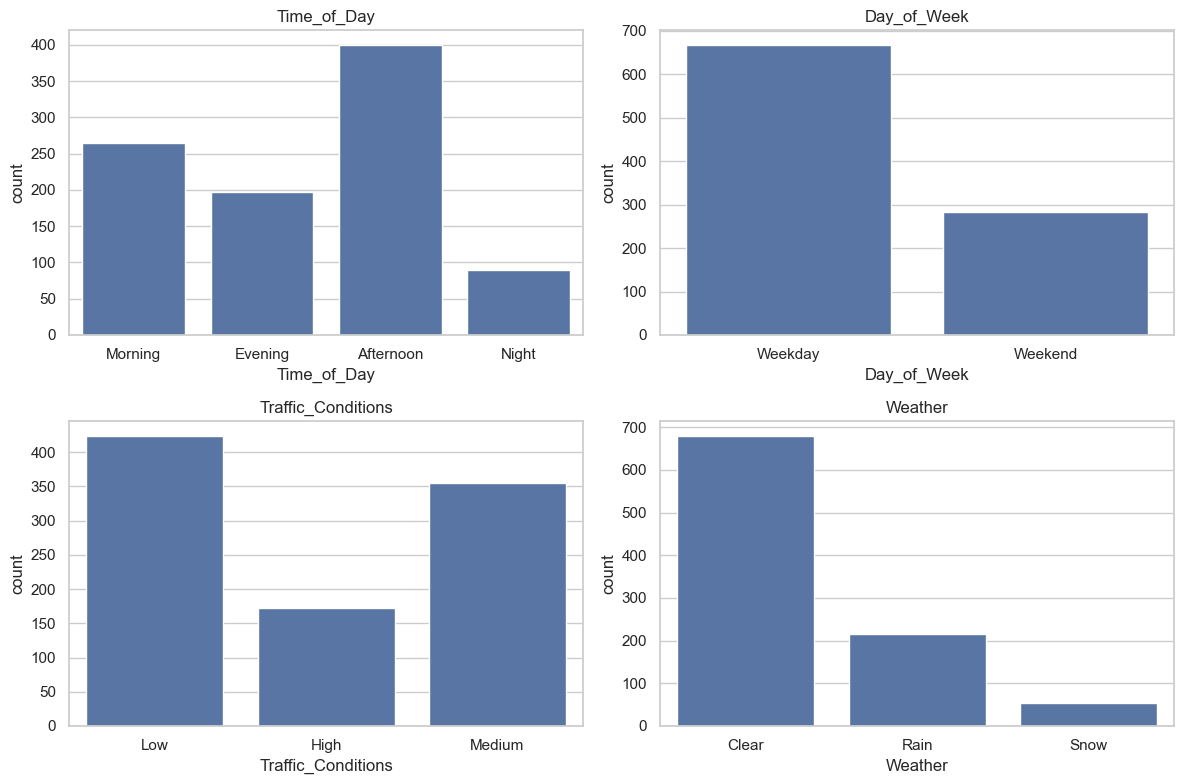

In [131]:
# Баланс категориальных признаков
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, c in zip(axes.flat, cat_cols):
    sns.countplot(data=df_clean, x=c, ax=ax)
    ax.set_title(c)
plt.tight_layout()
plt.show()

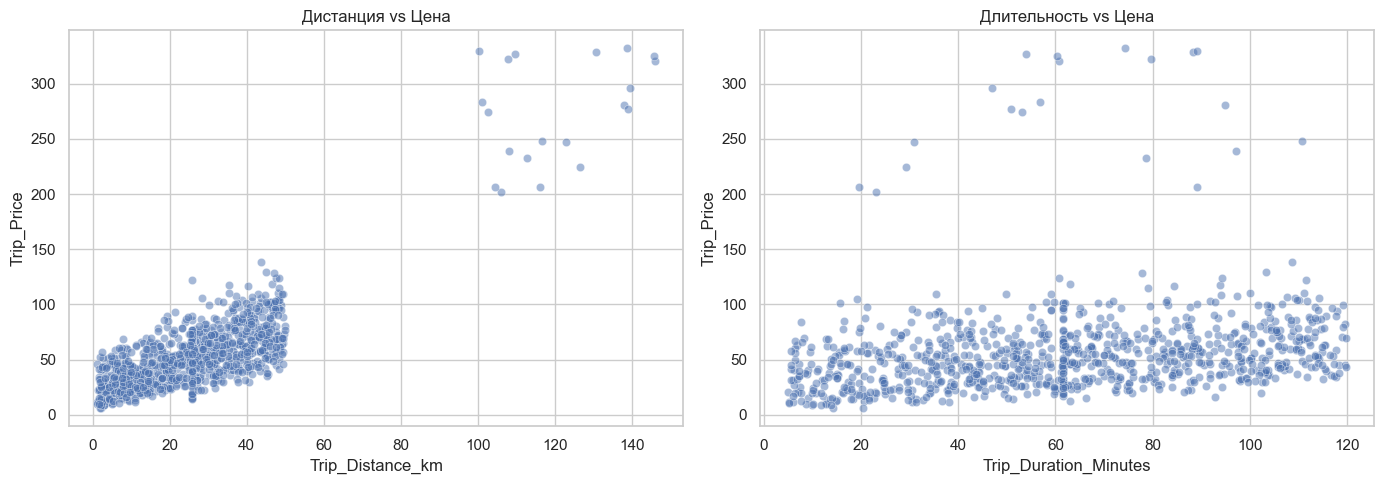

In [132]:
# Связь главных числовых признаков с ценой
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=df_clean, x="Trip_Distance_km", y="Trip_Price", alpha=0.5, ax=axes[0])
axes[0].set_title("Дистанция vs Цена")
sns.scatterplot(data=df_clean, x="Trip_Duration_Minutes", y="Trip_Price", alpha=0.5, ax=axes[1])
axes[1].set_title("Длительность vs Цена")
plt.tight_layout()
plt.show()

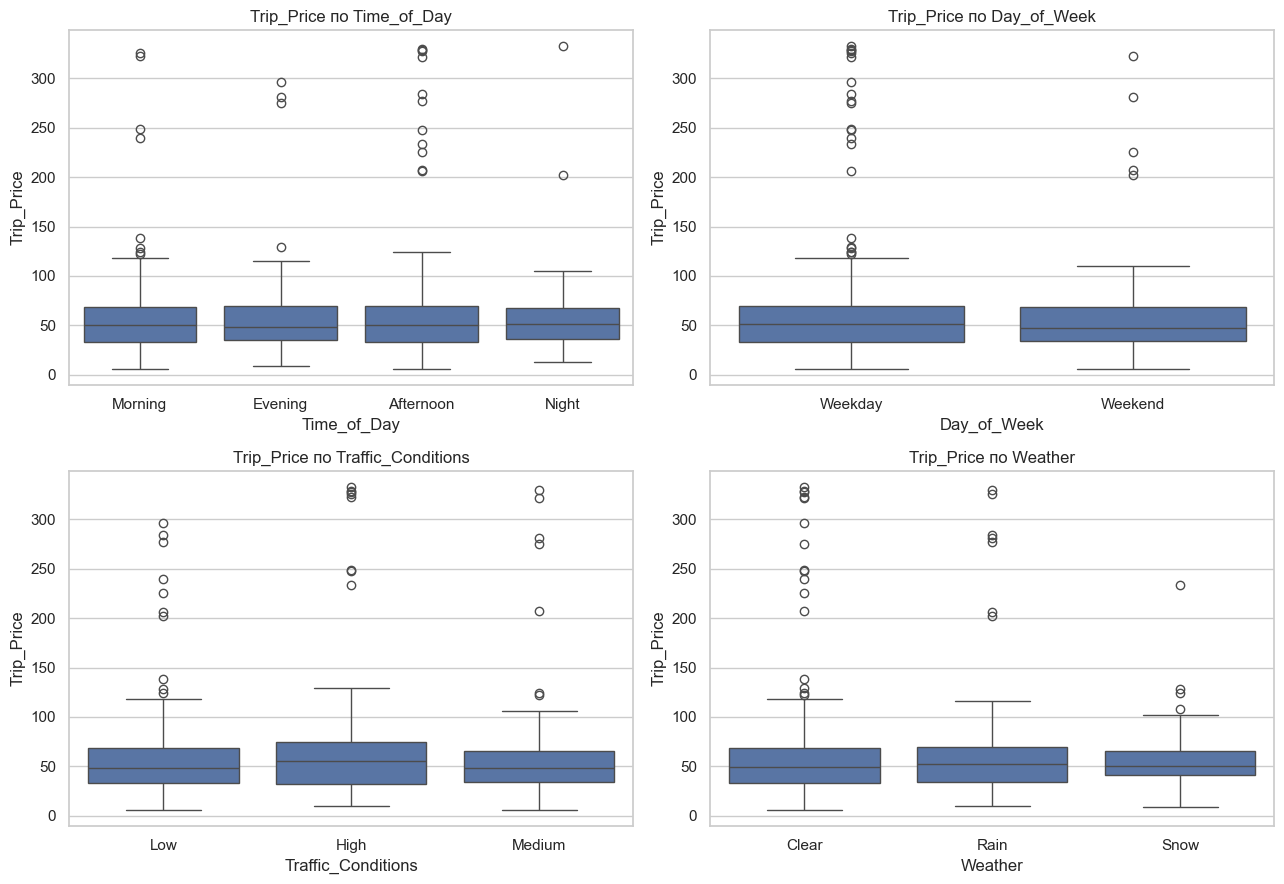

In [133]:
# Цена по категориям — двигают ли её Weather / Traffic / время / день?
cat_cols = ["Time_of_Day", "Day_of_Week", "Traffic_Conditions", "Weather"]
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, c in zip(axes.flat, cat_cols):
    sns.boxplot(data=df_clean, x=c, y="Trip_Price", ax=ax)
    ax.set_title(f"Trip_Price по {c}")
plt.tight_layout()
plt.show()

Training a Linear Regression Model

In [134]:
X = df_clean.drop(['Trip_Price','Time_of_Day', 'Day_of_Week', 'Traffic_Conditions', 'Weather' ],axis=1)
X.head()

,Trip_Distance_km,Passenger_Count,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes
0,19.35,3,3.56,0.80,0.32,53.82
2,36.87,1,2.70,1.21,0.15,37.27
3,30.33,4,3.48,0.51,0.15,116.81
4,25.87,3,2.93,0.63,0.32,22.64
5,8.64,2,2.55,1.71,0.48,89.33


In [135]:
y = df_clean['Trip_Price']
y.head()

0    36.2624
2    52.9032
3    36.4698
4    15.6180
5    60.2028
Name: Trip_Price, dtype: float64

Train Test Split

In [136]:
from sklearn.model_selection import train_test_split

In [137]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Creating and Training the Model

In [138]:
from sklearn.linear_model import LinearRegression

In [139]:
lm = LinearRegression()

In [140]:
lm.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [141]:
print(lm.coef_,lm.intercept_)

[ 1.70961285e+00 -2.23932077e-01 -5.15497401e-02  2.48799049e+01
  5.47623212e+01  3.03018483e-01] -54.26259391196305


Model Evaluation

In [142]:
coeff_df = pd.DataFrame(lm.coef_, X.columns,columns=['Coefficient'])
coeff_df

,Coefficient
Trip_Distance_km,1.709613
Passenger_Count,-0.223932
Base_Fare,-0.051550
Per_Km_Rate,24.879905
Per_Minute_Rate,54.762321
Trip_Duration_Minutes,0.303018


Predictions from our Model

In [143]:
X_test.shape

(191, 6)

In [144]:
predictions = lm.predict(X_test)

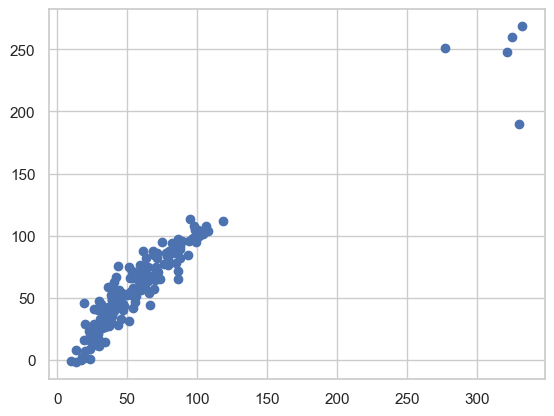

In [145]:
plt.scatter(y_test,predictions)

<Axes: xlabel='Trip_Price', ylabel='Count'>

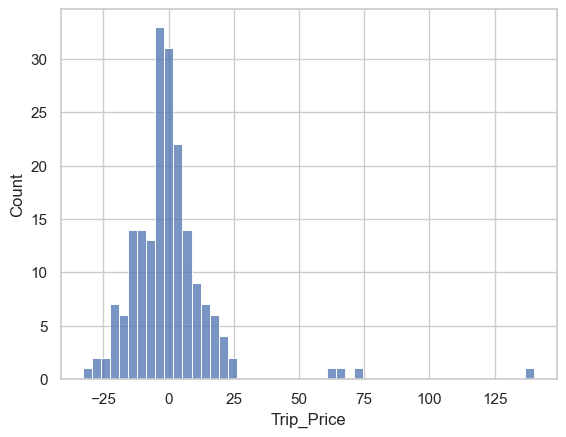

In [146]:
sns.histplot((y_test-predictions),bins=50)

## Почему коэффициенты отрицательные

`Base_Fare` (−0.05) и `Passenger_Count` (−0.22) вышли отрицательными. Это **не «обратное влияние»**, а артефакт:

- У обоих корреляция с ценой ≈ 0 (Passenger_Count −0.013, Base_Fare 0.035) → реального эффекта нет, коэффициент болтается у нуля, и шум случайно завёл его в минус. Знак почти-нулевого коэффициента не интерпретируем.
- `Base_Fare` физически обязан быть **+1** (он прямо прибавляется к цене), но модель этого «не видит».

**Корень проблемы:** настоящая цена = `Base_Fare + Per_Km_Rate·Distance + Per_Minute_Rate·Duration` — это *произведения* признаков. Линейная регрессия умеет только складывать, поэтому раскладывает каждое произведение на главные эффекты: коэффициент при `Per_Km_Rate` (24.9) ≈ средняя дистанция (27), при `Per_Minute_Rate` (54.8) ≈ средняя длительность (62), а intercept уезжает в −54 для компенсации.

**Что показывает проверка ниже (честный вердикт):**
- В очищенных данных цена **точно** равна формуле у **~78%** поездок.
- Отклонения у остальных — из двух источников:
  1. **Выбросы / surge**: ~2–3% поездок с завышенной ценой (до **3.3x**), не объяснимы признаками — это правый хвост из распределения цели.
  2. **Наша импутация**: медиана, которой мы заполнили пропуски в `Per_Km_Rate`/`Distance`/и т.д., не равна реальному значению → формула для этих строк перестаёт сходиться. То есть очистка имеет цену. (На строках вообще без пропусков совпадение — **97.5%**.)
- Если взять признаки-произведения (`km_cost`, `min_cost`) и оставить только «формульные» поездки — связь восстанавливается **идеально**: R²=1, коэффициенты ровно (1, 1, 1), intercept=0.

**Вывод:** высокий R² (~0.88) — это не «магия модели», а почти детерминированная формула; остаток ошибки сидит в выбросах и в шуме от импутации. Правильный следующий шаг — разбираться с выбросами, а не добавлять признаки.

In [147]:
# Гипотеза: Trip_Price = Base_Fare + Per_Km_Rate*Distance + Per_Minute_Rate*Duration
df_fe = df_clean.copy()
df_fe["km_cost"]  = df_fe["Per_Km_Rate"] * df_fe["Trip_Distance_km"]
df_fe["min_cost"] = df_fe["Per_Minute_Rate"] * df_fe["Trip_Duration_Minutes"]
df_fe["formula"]  = df_fe["Base_Fare"] + df_fe["km_cost"] + df_fe["min_cost"]

ratio = df_fe["Trip_Price"] / df_fe["formula"]
print("Цена == формуле (±1%):", round(ratio.between(0.99, 1.01).mean() * 100, 1), "%")
print("Макс. превышение над формулой:", round(ratio.max(), 2), "x  (surge / выбросы)")

# На поездках, что следуют формуле, связь восстанавливается идеально
mask = ratio.between(0.99, 1.01)
feats = ["Base_Fare", "km_cost", "min_cost"]
lm_f = LinearRegression().fit(df_fe.loc[mask, feats], df_fe.loc[mask, "Trip_Price"])

print("\nБез выбросов  R²:", round(lm_f.score(df_fe.loc[mask, feats], df_fe.loc[mask, "Trip_Price"]), 4))
print(pd.Series(lm_f.coef_, index=feats).round(3))
print("intercept:", round(lm_f.intercept_, 3))

Цена == формуле (±1%): 78.4 %
Макс. превышение над формулой: 3.27 x  (surge / выбросы)

Без выбросов  R²: 1.0
Base_Fare    0.999
km_cost      1.000
min_cost     1.000
dtype: float64
intercept: -0.0


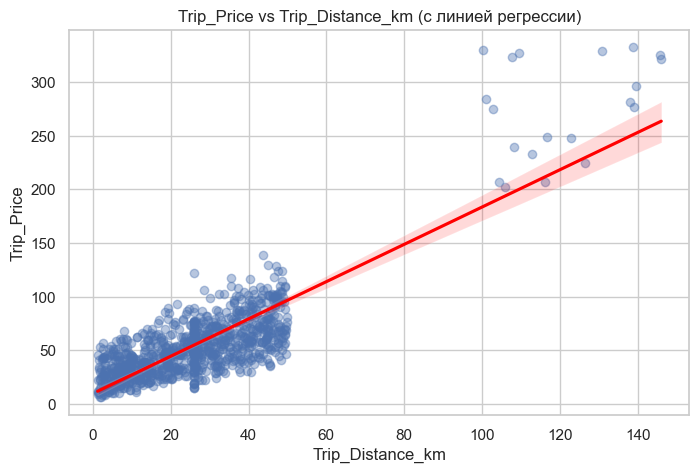

In [148]:
# Линейный график «признак -> цена» имеет смысл для ОДНОГО признака.
# Берём главный драйвер цены — Trip_Distance_km — со scatter и линией регрессии.
plt.figure(figsize=(8, 5))
sns.regplot(data=df_clean, x="Trip_Distance_km", y="Trip_Price",
            scatter_kws={"alpha": 0.4}, line_kws={"color": "red"})
plt.title("Trip_Price vs Trip_Distance_km (с линией регрессии)")
plt.show()

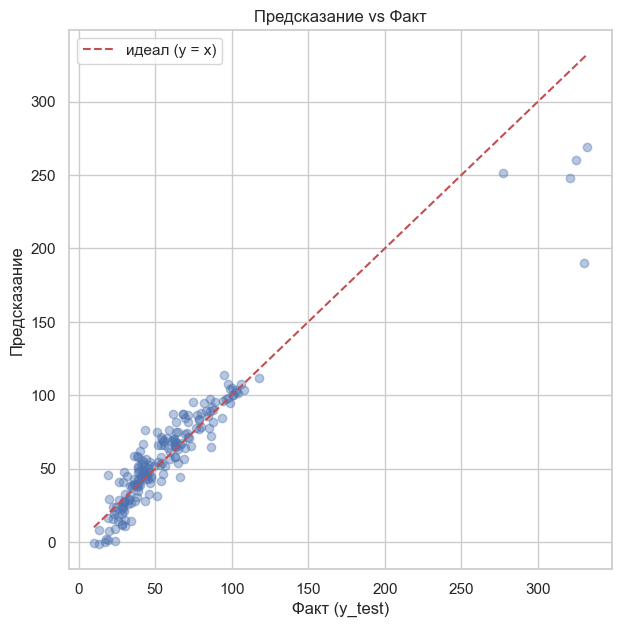

In [149]:
# Предсказание vs факт: идеальная модель легла бы на красную диагональ y=x
plt.figure(figsize=(7, 7))
plt.scatter(y_test, predictions, alpha=0.4)
lims = [y_test.min(), y_test.max()]
plt.plot(lims, lims, "r--", label="идеал (y = x)")
plt.xlabel("Факт (y_test)")
plt.ylabel("Предсказание")
plt.title("Предсказание vs Факт")
plt.legend()
plt.show()

## Кодирование категориальных признаков

Линейная регрессия принимает только числа, поэтому `Time_of_Day`, `Day_of_Week`, `Traffic_Conditions`, `Weather` переводим в числовые колонки методом **one-hot** (`pd.get_dummies`): каждая категория → отдельный столбец 0/1.

- `drop_first=True` убирает по одной категории из каждого признака (базовая категория), чтобы избежать мультиколлинеарности (dummy-ловушка).
- `dtype=int` делает значения 0/1, а не True/False.

Например `Time_of_Day` (Morning/Afternoon/Evening/Night) → `Time_of_Day_Evening`, `Time_of_Day_Morning`, `Time_of_Day_Night` (Afternoon — базовая).

In [150]:
# Кодируем категориальные признаки в числовые (one-hot, 0/1)
cat_cols = ["Time_of_Day", "Day_of_Week", "Traffic_Conditions", "Weather"]
df_encoded = pd.get_dummies(df_clean, columns=cat_cols, drop_first=True, dtype=int)

print("Было колонок:", df_clean.shape[1], "-> стало:", df_encoded.shape[1])
print("Новые числовые колонки из категорий:")
print([c for c in df_encoded.columns if c not in df_clean.columns])
df_encoded.head()

Было колонок: 11 -> стало: 15
Новые числовые колонки из категорий:
['Time_of_Day_Evening', 'Time_of_Day_Morning', 'Time_of_Day_Night', 'Day_of_Week_Weekend', 'Traffic_Conditions_Low', 'Traffic_Conditions_Medium', 'Weather_Rain', 'Weather_Snow']


,Trip_Distance_km,Passenger_Count,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price,Time_of_Day_Evening,Time_of_Day_Morning,Time_of_Day_Night,Day_of_Week_Weekend,Traffic_Conditions_Low,Traffic_Conditions_Medium,Weather_Rain,Weather_Snow
0,19.35,3,3.56,0.80,0.32,53.82,36.2624,0,1,0,0,1,0,0,0
2,36.87,1,2.70,1.21,0.15,37.27,52.9032,1,0,0,1,0,0,0,0
3,30.33,4,3.48,0.51,0.15,116.81,36.4698,1,0,0,0,1,0,0,0
4,25.87,3,2.93,0.63,0.32,22.64,15.6180,1,0,0,0,0,0,0,0
5,8.64,2,2.55,1.71,0.48,89.33,60.2028,0,0,0,1,0,1,0,0


## Полином, регуляризация и градиентный спуск

Сравниваем на одном тесте:
- **Linear** — базовая линейная регрессия (аналитическое решение).
- **Ridge / Lasso / ElasticNet** — регуляризация (штраф на коэффициенты, борьба с переобучением).
- **SGD** — та же линейная регрессия, но обучается **градиентным спуском** (проверяем, сходится ли к тому же результату).
- **Poly(2)** — полиномиальные признаки степени 2: создают произведения признаков (в т.ч. `Per_Km_Rate·Distance`, `Per_Minute_Rate·Duration` — настоящую формулу цены).

Перед всеми моделями — `StandardScaler` (регуляризация и градиентный спуск чувствительны к масштабу). Метрики на тесте: **R²** и **RMSE**.

In [151]:
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import Ridge, Lasso, ElasticNet, SGDRegressor
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score, mean_squared_error

# Признаки = все числовые (включая закодированные категории), цель = Trip_Price
Xc = df_encoded.drop("Trip_Price", axis=1)
yc = df_encoded["Trip_Price"]
Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(Xc, yc, test_size=0.2, random_state=42)

models = {
    "Linear":            make_pipeline(StandardScaler(), LinearRegression()),
    "Ridge":             make_pipeline(StandardScaler(), Ridge(alpha=1.0)),
    "Lasso":             make_pipeline(StandardScaler(), Lasso(alpha=0.1, max_iter=5000)),
    "ElasticNet":        make_pipeline(StandardScaler(), ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=5000)),
    "SGD (град. спуск)": make_pipeline(StandardScaler(), SGDRegressor(max_iter=2000, random_state=42)),
    "Poly(2) + Linear":  make_pipeline(StandardScaler(), PolynomialFeatures(2, include_bias=False), LinearRegression()),
    "Poly(2) + Ridge":   make_pipeline(StandardScaler(), PolynomialFeatures(2, include_bias=False), Ridge(alpha=1.0)),
}

rows = []
for name, m in models.items():
    m.fit(Xc_tr, yc_tr)
    p = m.predict(Xc_te)
    rows.append({"model": name,
                 "R2_test": r2_score(yc_te, p),
                 "RMSE_test": mean_squared_error(yc_te, p) ** 0.5})

results = pd.DataFrame(rows).sort_values("R2_test", ascending=False).reset_index(drop=True)
results.round(4)

,model,R2_test,RMSE_test
0,Poly(2) + Ridge,0.9048,14.9206
1,Poly(2) + Linear,0.9047,14.9271
2,SGD (град. спуск),0.8762,17.0094
3,Linear,0.8761,17.0151
4,Ridge,0.8759,17.0312
5,Lasso,0.8757,17.0440
6,ElasticNet,0.8656,17.7255


/var/folders/ph/mnfl_fnx1lxfylcfnh1hmt1c0000gn/T/ipykernel_91692/1860432564.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results, x="R2_test", y="model", palette="viridis")


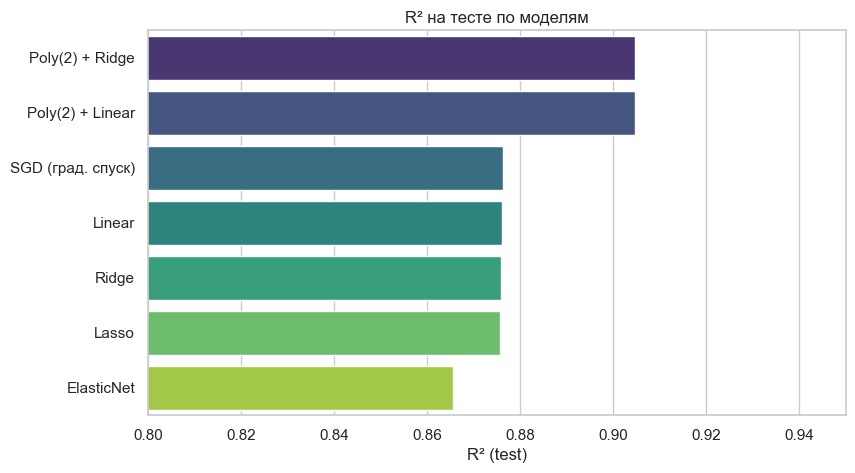

In [152]:
# Сравнение R² на тесте
plt.figure(figsize=(9, 5))
sns.barplot(data=results, x="R2_test", y="model", palette="viridis")
plt.xlim(0.8, 0.95)
plt.title("R² на тесте по моделям")
plt.xlabel("R² (test)")
plt.ylabel("")
plt.show()

### Честный вердикт по моделям

- **Регуляризация не помогает.** Ridge, Lasso ≈ обычная Linear (R²≈0.876). Бороться не с чем: признаков мало, переобучения нет. ElasticNet даже чуть хуже — лишний штраф занижает. Вывод: регуляризация — лекарство от переобучения, а у нас его нет.
- **Градиентный спуск работает.** SGD выходит на тот же R²≈0.876, что и аналитическое решение OLS → спуск корректно сходится к оптимуму.
- **Полином — единственный реальный прирост** (R² 0.876 → **0.905**). Степень 2 создаёт произведения признаков, в т.ч. `Per_Km_Rate·Distance` и `Per_Minute_Rate·Duration` — настоящую формулу цены, которую плоская линейная модель уловить не могла.
- **Потолок ~0.90** упирается в выбросы (surge-поездки до 3.3x): их не объяснить признаками. Дальше R² рос бы только через обработку выбросов, а не через новые модели.

## Диагноз: недообучение или переобучение?

Ставим диагноз тремя инструментами:
1. **Train vs Test R²** — разрыв между ними (gap). Маленький gap при низком качестве → недообучение (high bias); большой gap (train ≫ test) → переобучение (high variance).
2. **Кривые обучения** — как train- и validation-score ведут себя при росте данных. Сходятся к низкому потолку с малым зазором → недообучение. Большой устойчивый зазор → переобучение.
3. **График остатков** — есть ли в ошибках структура (тогда модель что-то систематически не уловила).

In [153]:
# 1) Train vs Test R² + разрыв (gap)
diag_models = {
    "Linear":  make_pipeline(StandardScaler(), LinearRegression()),
    "Poly(2)": make_pipeline(StandardScaler(), PolynomialFeatures(2, include_bias=False), LinearRegression()),
}
diag = []
for name, m in diag_models.items():
    m.fit(Xc_tr, yc_tr)
    r2_tr = r2_score(yc_tr, m.predict(Xc_tr))
    r2_te = r2_score(yc_te, m.predict(Xc_te))
    diag.append({"model": name, "R2_train": r2_tr, "R2_test": r2_te, "gap": r2_tr - r2_te})

pd.DataFrame(diag).round(4)

,model,R2_train,R2_test,gap
0,Linear,0.8575,0.8761,-0.0186
1,Poly(2),0.9600,0.9047,0.0553


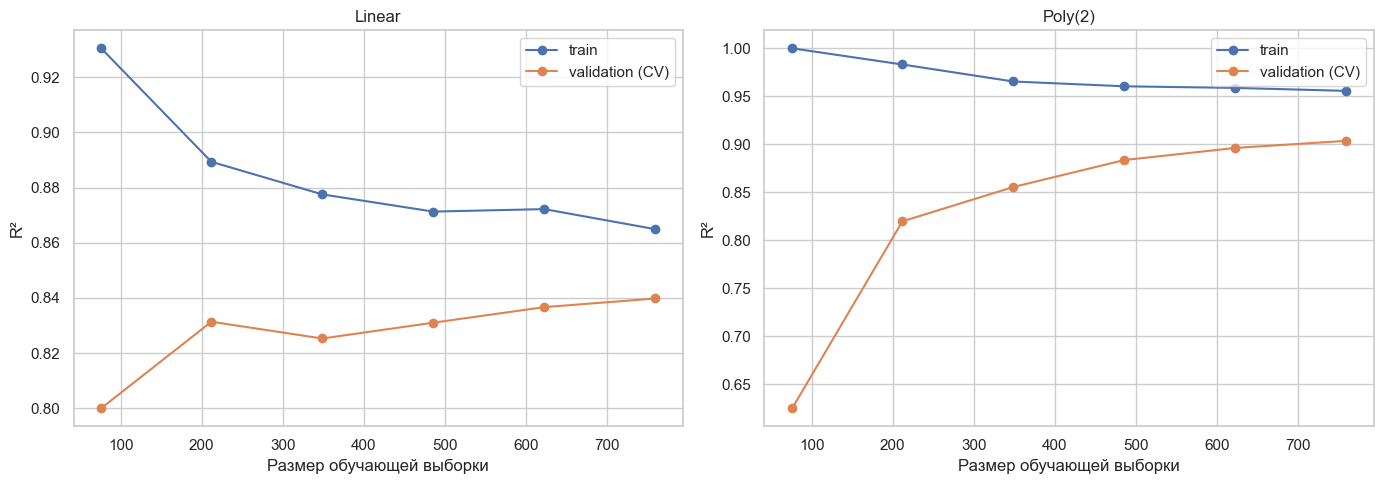

In [154]:
# 2) Кривые обучения: Linear vs Poly(2)
from sklearn.model_selection import learning_curve

def plot_lc(model, title, ax):
    sizes, tr, va = learning_curve(model, Xc, yc, cv=5,
                                   train_sizes=np.linspace(0.1, 1.0, 6),
                                   scoring="r2", random_state=0)
    ax.plot(sizes, tr.mean(axis=1), "o-", label="train")
    ax.plot(sizes, va.mean(axis=1), "o-", label="validation (CV)")
    ax.set_title(title)
    ax.set_xlabel("Размер обучающей выборки")
    ax.set_ylabel("R²")
    ax.legend()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_lc(make_pipeline(StandardScaler(), LinearRegression()), "Linear", axes[0])
plot_lc(make_pipeline(StandardScaler(), PolynomialFeatures(2, include_bias=False), LinearRegression()),
        "Poly(2)", axes[1])
plt.tight_layout()
plt.show()

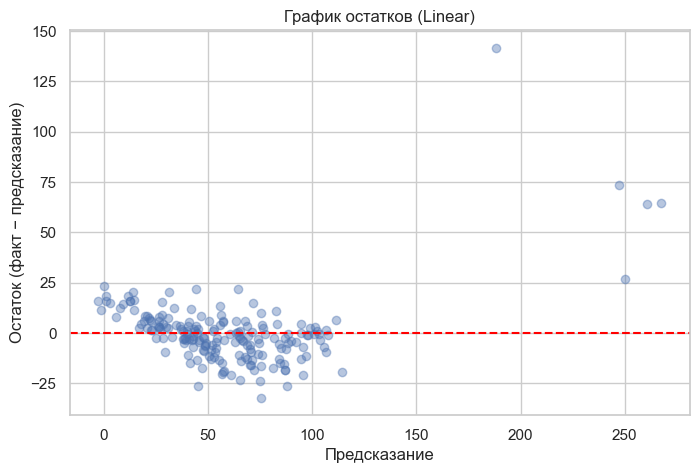

In [155]:
# 3) График остатков для базовой Linear-модели
lin = make_pipeline(StandardScaler(), LinearRegression()).fit(Xc_tr, yc_tr)
pred_te = lin.predict(Xc_te)
resid = yc_te - pred_te

plt.figure(figsize=(8, 5))
plt.scatter(pred_te, resid, alpha=0.4)
plt.axhline(0, color="red", ls="--")
plt.xlabel("Предсказание")
plt.ylabel("Остаток (факт − предсказание)")
plt.title("График остатков (Linear)")
plt.show()

### Диагноз

| Модель | R² train | R² test | gap |
|---|---|---|---|
| Linear | 0.857 | 0.876 | ≈0 (test даже выше) |
| Poly(2) | 0.960 | 0.905 | ~0.055 |

- **Базовая Linear → НЕДООБУЧЕНИЕ (high bias).** Train и test почти равны (≈0.86–0.88), а на кривых обучения train- и validation-линии **сходятся к невысокому потолку с маленьким зазором**. Это классика недообучения: модель слишком простая для мультипликативной формулы цены. Больше данных не поможет (кривые уже плоские) — нужны более богатые признаки.
- **Poly(2) → почти оптимум, лёгкая дисперсия.** Train 0.96 > test 0.905 — зазор появился, но небольшой, а test высокий. Это не патологическое переобучение; небольшой разрыв при желании поджимается регуляризацией (Poly(2)+Ridge).
- **График остатков** базовой модели: большинство остатков у нуля (поездки = формуле), но виден кластер крупных **положительных** выбросов — это surge-поездки, которые модель систематически недооценивает. То есть ошибка не случайна, а структурна → подтверждает, что простая модель чего-то не видит.

**Итог диагноза:** проблема — **недообучение** простой линейной модели (а не переобучение). Лечение, что и подтвердилось: полиномиальные признаки (произведения), а оставшийся потолок ~0.90 держат выбросы.

## Помогли ли закодированные категории?

Категориальные признаки мы корректно перевели в числа (one-hot). Но дали ли они прирост качества? Сравниваем на одном split линейную модель **только на числовых** vs **числовые + one-hot категории**.

In [156]:
# Только числовые
num_only = ["Trip_Distance_km", "Passenger_Count", "Base_Fare",
            "Per_Km_Rate", "Per_Minute_Rate", "Trip_Duration_Minutes"]
Xn = df_clean[num_only]
Xn_tr, Xn_te, yn_tr, yn_te = train_test_split(Xn, df_clean["Trip_Price"], test_size=0.2, random_state=42)
m_num = make_pipeline(StandardScaler(), LinearRegression()).fit(Xn_tr, yn_tr)

# Числовые + one-hot категории (df_encoded, тот же split — Xc_tr / Xc_te)
m_cat = make_pipeline(StandardScaler(), LinearRegression()).fit(Xc_tr, yc_tr)

print("Только числовые      R2 =", round(r2_score(yn_te, m_num.predict(Xn_te)), 4),
      f"({Xn.shape[1]} призн.)")
print("Числовые + категории R2 =", round(r2_score(yc_te, m_cat.predict(Xc_te)), 4),
      f"({Xc.shape[1]} призн.)")

Только числовые      R2 = 0.8769 (6 призн.)
Числовые + категории R2 = 0.8761 (14 призн.)


### Вердикт: категории не помогли

| Признаки | R² test |
|---|---|
| Только числовые (6) | **0.8769** |
| Числовые + one-hot категории (14) | 0.8761 |

R² не вырос, а даже чуть просел. Причина: цена — детерминированная формула от числовых признаков (`Base_Fare + ставка·дистанция + ставка·время`), а `Time_of_Day`/`Weather`/`Traffic`/`Day_of_Week` в неё не входят (это видно по boxplot'ам — цена по категориям почти не меняется). Кодирование сделано **методически верно**, но эти признаки **нерелевантны цели**: 8 лишних колонок добавили чуть дисперсии без сигнала. Честный вывод — не каждый признак полезен.

## Сходимость градиентного спуска (эпохи)

`SGDRegressor` с лимитом `max_iter=2000` реально остановился на **38 эпохе** (`n_iter_`) — сработала ранняя остановка по `tol`. Покажем это: обучаем по одной эпохе (`partial_fit`) и строим RMSE по эпохам. Ошибка быстро падает и выходит на плато — после ~38 эпох улучшения почти нет, поэтому остальные 1962 эпохи не нужны.

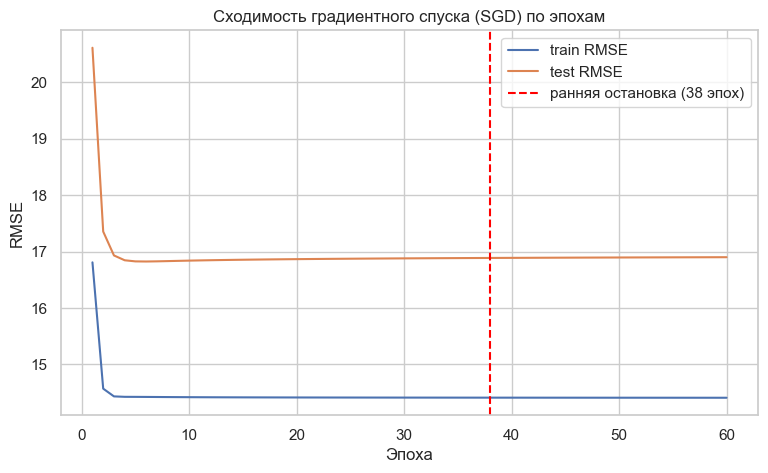

In [157]:
from sklearn.metrics import mean_squared_error

# Масштабируем (SGD чувствителен к масштабу)
scaler = StandardScaler().fit(Xc_tr)
Xtr_s = scaler.transform(Xc_tr)
Xte_s = scaler.transform(Xc_te)

# Обучаем по ОДНОЙ эпохе за раз (partial_fit) и пишем ошибку после каждой
sgd_ep = SGDRegressor(random_state=42, warm_start=True, max_iter=1, tol=None)
train_rmse, test_rmse = [], []
for ep in range(60):
    sgd_ep.partial_fit(Xtr_s, yc_tr)
    train_rmse.append(mean_squared_error(yc_tr, sgd_ep.predict(Xtr_s)) ** 0.5)
    test_rmse.append(mean_squared_error(yc_te, sgd_ep.predict(Xte_s)) ** 0.5)

plt.figure(figsize=(9, 5))
plt.plot(range(1, 61), train_rmse, label="train RMSE")
plt.plot(range(1, 61), test_rmse, label="test RMSE")
plt.axvline(38, color="red", ls="--", label="ранняя остановка (38 эпох)")
plt.xlabel("Эпоха")
plt.ylabel("RMSE")
plt.title("Сходимость градиентного спуска (SGD) по эпохам")
plt.legend()
plt.show()

## Финальный честный вердикт: где модель надёжна, а где врёт

Берём лучшую модель (Poly(2)+Ridge) и оцениваем ошибку «по-человечески»:
1. сравниваем RMSE с **средним** и **разбросом (std)** цели;
2. смотрим **5 поездок с самой большой ошибкой**;
3. формулируем словами, где модели можно доверять, а где нет.

In [158]:
# RMSE лучшей модели vs среднее и разброс цели
best = models["Poly(2) + Ridge"]
pred_best = best.predict(Xc_te)
rmse_best = mean_squared_error(yc_te, pred_best) ** 0.5

print(f"RMSE лучшей модели:  {rmse_best:.2f}")
print(f"Цель Trip_Price  —  mean: {yc_te.mean():.2f}   std: {yc_te.std():.2f}")
print(f"RMSE / std  = {rmse_best / yc_te.std():.2f}   (ошибка ~{rmse_best / yc_te.std() * 100:.0f}% от разброса)")
print(f"RMSE / mean = {100 * rmse_best / yc_te.mean():.0f}%   (ошибка ~четверть средней цены)")

RMSE лучшей модели:  14.92
Цель Trip_Price  —  mean: 60.23   std: 48.47
RMSE / std  = 0.31   (ошибка ~31% от разброса)
RMSE / mean = 25%   (ошибка ~четверть средней цены)


In [159]:
# 5 поездок с самой большой ошибкой (по модулю остатка)
resid_best = yc_te - pred_best
top5 = resid_best.abs().sort_values(ascending=False).head(5).index

worst = df_clean.loc[top5, ["Trip_Distance_km", "Trip_Duration_Minutes",
                            "Per_Km_Rate", "Per_Minute_Rate"]].copy()
worst["actual"]   = yc_te.loc[top5].round(1)
worst["pred"]     = pd.Series(pred_best, index=yc_te.index).loc[top5].round(1)
worst["residual"] = resid_best.loc[top5].round(1)
worst

,Trip_Distance_km,Trip_Duration_Minutes,Per_Km_Rate,Per_Minute_Rate,actual,pred,residual
287,100.380420,89.21,1.22,0.29,329.9,192.7,137.2
268,139.062230,50.83,1.82,0.14,276.8,368.1,-91.3
616,138.763887,74.32,1.71,0.39,332.0,402.4,-70.3
64,146.067047,60.81,0.73,0.30,321.0,285.0,36.0
770,25.870000,61.57,0.98,0.24,19.1,45.1,-26.0


### Вывод простыми словами

**Насколько хороша ошибка.** RMSE ≈ **14.9** при разбросе цены std ≈ **48.5** и средней ≈ **60.2**. То есть типичная ошибка модели — около **0.31 от разброса** и **~25% от средней цены**. Это заметно лучше, чем «угадывать среднее» (тогда ошибка ≈ std = 48.5): модель срезает ошибку примерно втрое.

**Где модель надёжна.** На обычных поездках — короткой и средней дистанции, цена которых считается по стандартному тарифу (`Base_Fare + ставка·км + ставка·мин`). Это ~78–97% поездок; для них предсказание почти точное, остаток близок к нулю.

**Где модель ошибается.** Все 5 худших случаев — это **очень длинные поездки (100–146 км) с экстремально высокой ценой (≈277–332)**, где сработал surge-множитель (до 3.3x). Модель его «не видит» (в признаках нет ничего про surge) и ошибается на **70–137 единиц**: то занижает (поездка дороже формулы), то завышает на самом краю диапазона, где данных мало (экстраполяция).

**Итог.** Модель надёжна для типичной поездки по тарифу, но ей **нельзя доверять оценку дорогих/сверхдлинных поездок** — там сидит вся крупная ошибка. Чтобы это починить, нужен признак про surge/наценку (которого в датасете нет), а не более сложная модель.